# Population Stratification in Latent Space

Checks how much population structure is present in **z_task** and **z_domain** before and after training,
by projecting each subspace with PCA and colouring by population label.

- **Pop 0** = CEU (discovery / source population)
- **Pop 1** = YRI (target population)

Pre- and post-training projections share the **same PCA fit** (trained on pre-training data from both splits
combined) so the axes are directly comparable.

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
# ── Configuration ────────────────────────────────────────────────────────────
EXP_DIR = Path("/sietch_colab/akapoor/XPopVAE/experiments/OOA/vae/0/rep1/default")
LATENTS_DIR = EXP_DIR / "vae_outputs" / "latents"

POP_NAMES   = {0: "CEU (disc train)", 1: "YRI (target train)"}
POP_COLORS  = {0: "#2166ac", 1: "#d6604d"}   # blue / red
N_COMPONENTS = 2    # PCs to compute (only first 2 are plotted)
ALPHA = 0.45
POINT_SIZE = 8

In [13]:
# ── Data loading ─────────────────────────────────────────────────────────────
def load_phase(latents_dir: Path, phase: str):
    """Return (z_task, z_domain, pop_labels) concatenated across both splits."""
    splits = ["disc_train", "target_train"]
    zt_parts, zd_parts, lab_parts = [], [], []
    for split in splits:
        zt  = np.load(latents_dir / f"{split}_{phase}_z_task.npy")
        zd  = np.load(latents_dir / f"{split}_{phase}_z_domain.npy")
        lab = np.load(latents_dir / f"{split}_{phase}_pop_labels.npy")
        zt_parts.append(zt)
        zd_parts.append(zd)
        lab_parts.append(lab)
    return (
        np.concatenate(zt_parts, axis=0),
        np.concatenate(zd_parts, axis=0),
        np.concatenate(lab_parts, axis=0),
    )

zt_pre,  zd_pre,  labels_pre  = load_phase(LATENTS_DIR, "pre_training")
zt_post, zd_post, labels_post = load_phase(LATENTS_DIR, "post_training")

print(f"pre  — z_task: {zt_pre.shape}   z_domain: {zd_pre.shape}   labels: {np.unique(labels_pre)}")
print(f"post — z_task: {zt_post.shape}  z_domain: {zd_post.shape}  labels: {np.unique(labels_post)}")

pre  — z_task: (981, 64)   z_domain: (981, 64)   labels: [0 1]
post — z_task: (981, 64)  z_domain: (981, 64)  labels: [0 1]


In [14]:
# ── Shared PCA helper ─────────────────────────────────────────────────────────
# Fit on the combined (pre + post) data so pre and post projections live in
# the exact same coordinate system and are directly comparable.
def make_shared_pca(data_pre: np.ndarray, data_post: np.ndarray, n_components: int = 2):
    combined = np.concatenate([data_pre, data_post], axis=0)
    scaler = StandardScaler()
    combined_scaled = scaler.fit_transform(combined)
    pca = PCA(n_components=n_components)
    pca.fit(combined_scaled)
    proj_pre  = pca.transform(scaler.transform(data_pre))
    proj_post = pca.transform(scaler.transform(data_post))
    return proj_pre, proj_post, pca.explained_variance_ratio_

In [15]:
# ── Fit shared PCAs ───────────────────────────────────────────────────────────
zt_proj_pre,  zt_proj_post,  zt_var  = make_shared_pca(zt_pre,  zt_post,  N_COMPONENTS)
zd_proj_pre,  zd_proj_post,  zd_var  = make_shared_pca(zd_pre,  zd_post,  N_COMPONENTS)

print(f"z_task  PCA explained variance: PC1={zt_var[0]:.3f}  PC2={zt_var[1]:.3f}")
print(f"z_domain PCA explained variance: PC1={zd_var[0]:.3f}  PC2={zd_var[1]:.3f}")

z_task  PCA explained variance: PC1=0.834  PC2=0.035
z_domain PCA explained variance: PC1=0.287  PC2=0.034


In [16]:
# ── Scatter helper ────────────────────────────────────────────────────────────
def scatter_pca(ax, proj: np.ndarray, labels: np.ndarray, var: np.ndarray, title: str):
    for pop_id in np.unique(labels):
        mask = labels == pop_id
        ax.scatter(
            proj[mask, 0], proj[mask, 1],
            c=POP_COLORS.get(pop_id, "grey"),
            label=POP_NAMES.get(pop_id, str(pop_id)),
            alpha=ALPHA, s=POINT_SIZE, linewidths=0,
        )
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, markerscale=2)

Saved → /sietch_colab/akapoor/XPopVAE/experiments/OOA/vae/0/rep1/default/vae_outputs/latents/pca_z_task_pop_stratification.png


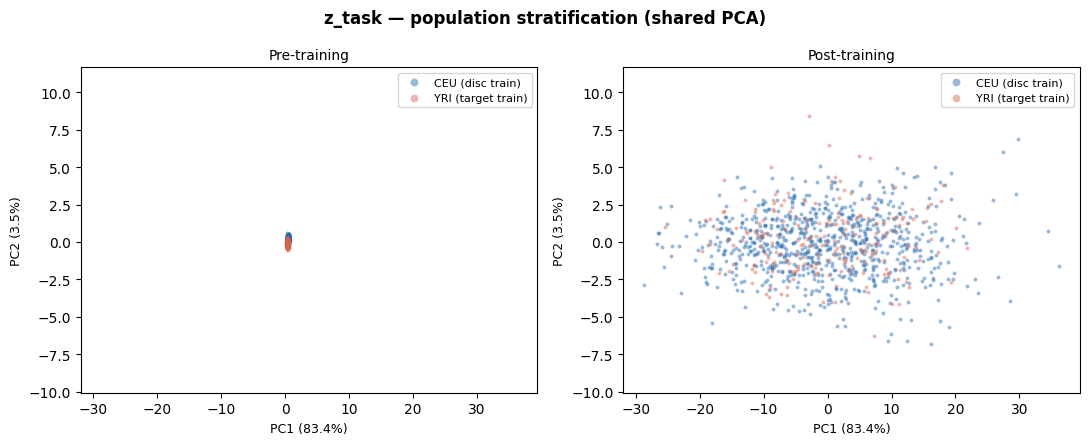

In [17]:
# ── Figure 1: z_task ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("z_task — population stratification (shared PCA)", fontsize=12, fontweight="bold")

scatter_pca(axes[0], zt_proj_pre,  labels_pre,  zt_var, "Pre-training")
scatter_pca(axes[1], zt_proj_post, labels_post, zt_var, "Post-training")

# fix axes ranges to be identical across panels
for ax in axes:
    all_x = np.concatenate([zt_proj_pre[:, 0], zt_proj_post[:, 0]])
    all_y = np.concatenate([zt_proj_pre[:, 1], zt_proj_post[:, 1]])
    pad = 0.05 * (all_x.max() - all_x.min())
    ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
    ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

plt.tight_layout()
out_path = EXP_DIR / "vae_outputs" / "latents" / "pca_z_task_pop_stratification.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

Saved → /sietch_colab/akapoor/XPopVAE/experiments/OOA/vae/0/rep1/default/vae_outputs/latents/pca_z_domain_pop_stratification.png


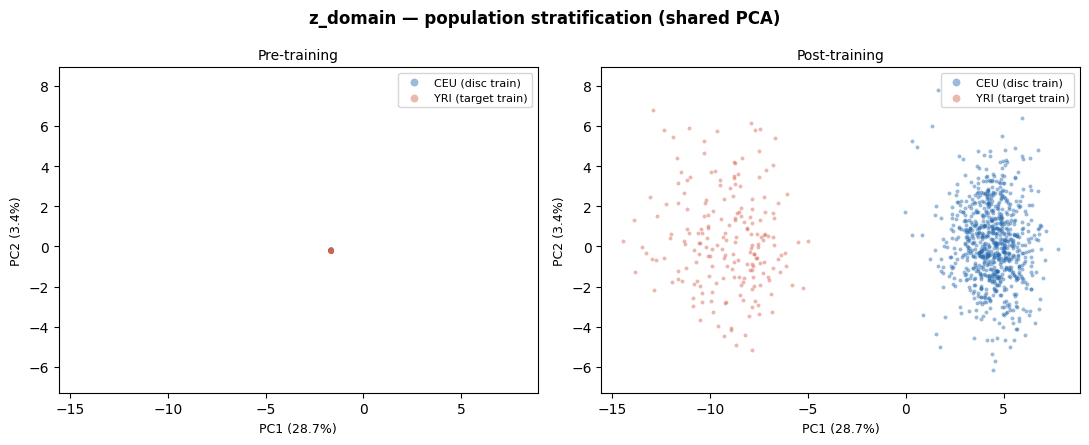

In [18]:
# ── Figure 2: z_domain ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("z_domain — population stratification (shared PCA)", fontsize=12, fontweight="bold")

scatter_pca(axes[0], zd_proj_pre,  labels_pre,  zd_var, "Pre-training")
scatter_pca(axes[1], zd_proj_post, labels_post, zd_var, "Post-training")

for ax in axes:
    all_x = np.concatenate([zd_proj_pre[:, 0], zd_proj_post[:, 0]])
    all_y = np.concatenate([zd_proj_pre[:, 1], zd_proj_post[:, 1]])
    pad = 0.05 * (all_x.max() - all_x.min())
    ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
    ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

plt.tight_layout()
out_path = EXP_DIR / "vae_outputs" / "latents" / "pca_z_domain_pop_stratification.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

Saved → /sietch_colab/akapoor/XPopVAE/experiments/OOA/vae/0/rep1/default/vae_outputs/latents/pca_overview_2x2.png


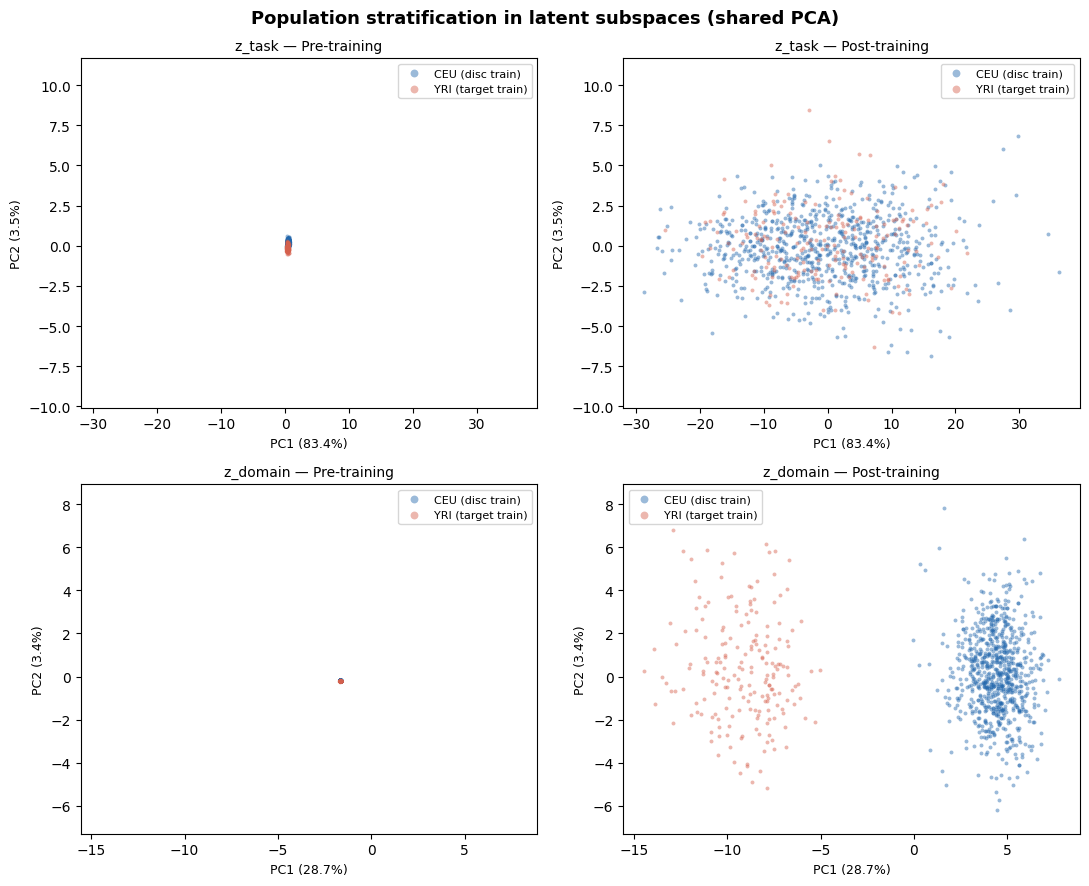

In [19]:
# ── Figure 3: 2×2 overview ───────────────────────────────────────────────────
# Rows = subspace (z_task / z_domain), Columns = phase (pre / post)
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle("Population stratification in latent subspaces (shared PCA)", fontsize=13, fontweight="bold")

scatter_pca(axes[0, 0], zt_proj_pre,  labels_pre,  zt_var, "z_task — Pre-training")
scatter_pca(axes[0, 1], zt_proj_post, labels_post, zt_var, "z_task — Post-training")
scatter_pca(axes[1, 0], zd_proj_pre,  labels_pre,  zd_var, "z_domain — Pre-training")
scatter_pca(axes[1, 1], zd_proj_post, labels_post, zd_var, "z_domain — Post-training")

# uniform axes per row
for row_axes, pre_proj, post_proj in [
    (axes[0], zt_proj_pre, zt_proj_post),
    (axes[1], zd_proj_pre, zd_proj_post),
]:
    all_x = np.concatenate([pre_proj[:, 0], post_proj[:, 0]])
    all_y = np.concatenate([pre_proj[:, 1], post_proj[:, 1]])
    pad = 0.05 * (all_x.max() - all_x.min())
    for ax in row_axes:
        ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
        ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

plt.tight_layout()
out_path = EXP_DIR / "vae_outputs" / "latents" / "pca_overview_2x2.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

In [20]:
# ── Quantitative: centroid separation ────────────────────────────────────────
# How far apart are the CEU and YRI centroids in PC space, relative to the
# overall spread?  A higher ratio = more stratification.
from sklearn.metrics import silhouette_score

def centroid_separation(proj, labels):
    pops = np.unique(labels)
    centroids = [proj[labels == p].mean(axis=0) for p in pops]
    dist = np.linalg.norm(centroids[0] - centroids[1])
    spread = proj.std(axis=0).mean()
    return dist / (spread + 1e-9)

print("Centroid separation (higher = more stratified):")
print(f"  z_task  pre : {centroid_separation(zt_proj_pre,  labels_pre):.3f}")
print(f"  z_task  post: {centroid_separation(zt_proj_post, labels_post):.3f}")
print(f"  z_domain pre : {centroid_separation(zd_proj_pre,  labels_pre):.3f}")
print(f"  z_domain post: {centroid_separation(zd_proj_post, labels_post):.3f}")

print()
print("Silhouette score (higher = more stratified, range [-1, 1]):")
for name, proj, lab in [
    ("z_task  pre",  zt_proj_pre,  labels_pre),
    ("z_task  post", zt_proj_post, labels_post),
    ("z_domain pre",  zd_proj_pre,  labels_pre),
    ("z_domain post", zd_proj_post, labels_post),
]:
    score = silhouette_score(proj, lab) if len(np.unique(lab)) > 1 else float('nan')
    print(f"  {name}: {score:.3f}")

Centroid separation (higher = more stratified):
  z_task  pre : 2.357
  z_task  post: 0.054
  z_domain pre : 1.833
  z_domain post: 3.537

Silhouette score (higher = more stratified, range [-1, 1]):
  z_task  pre: 0.400
  z_task  post: -0.032
  z_domain pre: 0.290
  z_domain post: 0.783
